In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm

In [21]:
data = pd.read_csv("../data/1.02. Multiple linear regression.csv")

In [22]:
data

,SAT,GPA,"Rand 1,2,3"
0,1714,2.40,1
1,1664,2.52,3
2,1760,2.54,3
3,1685,2.74,3
4,1693,2.83,2
...,...,...,...
79,1936,3.71,3
80,1810,3.71,1
81,1987,3.73,3
82,1962,3.76,1


In [23]:
data.describe()

,SAT,GPA,"Rand 1,2,3"
count,84.000000,84.000000,84.000000
mean,1845.273810,3.330238,2.059524
std,104.530661,0.271617,0.855192
min,1634.000000,2.400000,1.000000
25%,1772.000000,3.190000,1.000000
50%,1846.000000,3.380000,2.000000
75%,1934.000000,3.502500,3.000000
max,2050.000000,3.810000,3.000000


In [24]:
# 変数を定義する
y = data["GPA"]
x1 = data[["SAT", "Rand 1,2,3"]]

In [25]:
x = sm.add_constant(x1)
# 最小二乗法を使ってモデルを作成する
results = sm.OLS(y, x).fit()
# 結果を表示する
results.summary()

# 決定係数が前よりも高くなったため、説明力が上がっているとわかる
# しかし、自由度調整済み決定係数は前よりも低くなっているため、説明力が下がっているとも言える
# Rand1,2,3のp値が0.762であり、これは切片=0という帰無仮説を棄却できないため、Rand1,2,3はGPA推測モデルに含まないべきである

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    GPA   R-squared:                       0.407
Model:                            OLS   Adj. R-squared:                  0.392
Method:                 Least Squares   F-statistic:                     27.76
Date:                Sat, 22 Jun 2024   Prob (F-statistic):           6.58e-10
Time:                        18:34:20   Log-Likelihood:                 12.720
No. Observations:                  84   AIC:                            -19.44
Df Residuals:                      81   BIC:                            -12.15
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2960      0.417      0.710      0.480      -0.533       1.125
SAT            0.0017      0.000      7.432      0.000       0.001       0.002
Rand 1,2,3    -0.0083      0.027     -0.304      0.762      -0.062       0.046
==============================================================================
Omnibus:                       12.992   Durbin-Watson:                   0.948
Prob(Omnibus):                  0.002   Jarque-Bera (JB):               16.364
Skew:                          -0.731   Prob(JB):                     0.000280
Kurtosis:                       4.594   Cond. No.                     3.33e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.33e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

ValueError: x and y must be the same size

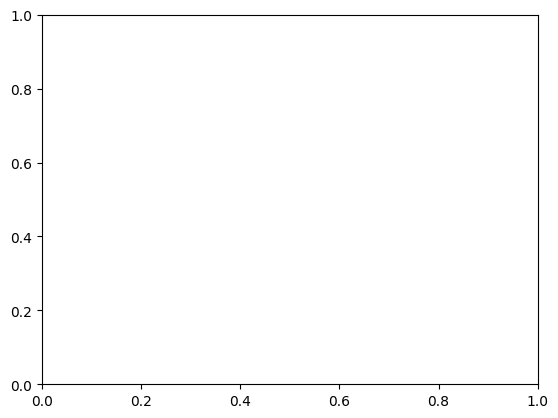

In [26]:
plt.scatter(x1, y)
# 予測値をプロットする
yhat = 0.0017 * x1 + 0.275
fig = plt.plot(x1, yhat, lw=4, c="orange", label="regression line")
plt.xlabel("SAT", fontsize=20)
plt.ylabel("GPA", fontsize=20)
plt.show()